**Import Libraries**

In [35]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

import statsmodels.api as sm

In [56]:
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

**Load the Dataset**

In [5]:
df=pd.read_csv("iris.csv")

**View the first few rows**

In [6]:
df.head()

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


**Check dataset Information**

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   sepal_length  150 non-null    float64
 1   sepal_width   150 non-null    float64
 2   petal_length  150 non-null    float64
 3   petal_width   150 non-null    float64
 4   species       150 non-null    object 
dtypes: float64(4), object(1)
memory usage: 6.0+ KB


**Checking Missing Values**

In [8]:
df.isnull().sum()

sepal_length    0
sepal_width     0
petal_length    0
petal_width     0
species         0
dtype: int64

**Checking Duplicate Rows**

In [9]:
df.duplicated().sum()

np.int64(3)

In [10]:
df=df.drop_duplicates()

In [11]:
df.duplicated().sum()

np.int64(0)

**Standardize Categorical Data**

In [12]:
df["species"] = df["species"].str.title()

In [13]:
df.species

0         Setosa
1         Setosa
2         Setosa
3         Setosa
4         Setosa
         ...    
145    Virginica
146    Virginica
147    Virginica
148    Virginica
149    Virginica
Name: species, Length: 147, dtype: object

**Summary of all statistics together**

In [14]:
df.describe()

,sepal_length,sepal_width,petal_length,petal_width
count,147.000000,147.000000,147.000000,147.000000
mean,5.856463,3.055782,3.780272,1.208844
std,0.829100,0.437009,1.759111,0.757874
min,4.300000,2.000000,1.000000,0.100000
25%,5.100000,2.800000,1.600000,0.300000
50%,5.800000,3.000000,4.400000,1.300000
75%,6.400000,3.300000,5.100000,1.800000
max,7.900000,4.400000,6.900000,2.500000


**Histogram**

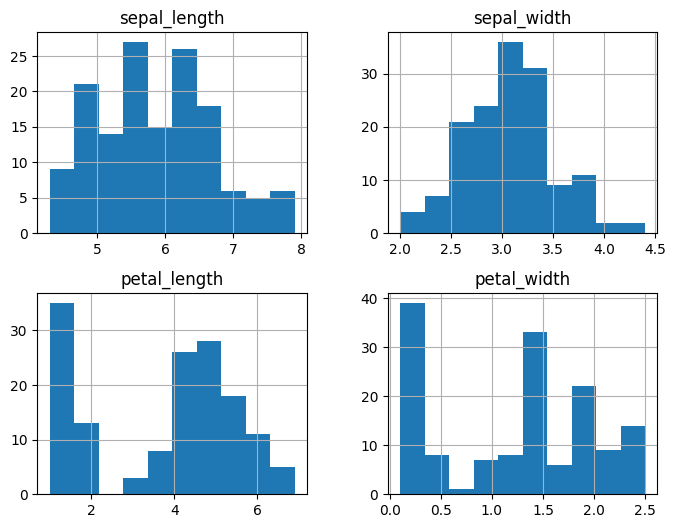

In [15]:
df.hist(figsize=(8,6))
plt.show()

<p style="text-align: justify;">The histogram shows the distribution of each numerical feature in the Iris dataset. Most measurements are concentrated within specific ranges, indicating that the data is fairly balanced with no major gaps. It also helps identify the spread and frequency of values for each feature.</p>

**BoxPlot**

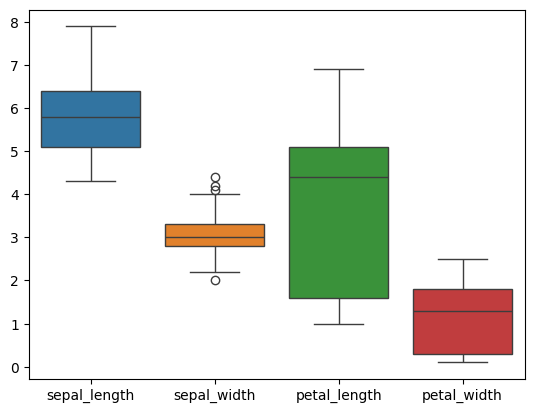

In [16]:
sns.boxplot(data=df)
plt.show()

<p style="text-align: justify;">The boxplot summarizes the distribution of the numerical features and highlights the median and quartiles and any potential outliers. Most features have a consistent spread, while a few values may appear as outliers. This visualization is useful for understanding data variability.</p>

**Correlation and Heatmap**

In [17]:
df.corr(numeric_only=True)

,sepal_length,sepal_width,petal_length,petal_width
sepal_length,1.000000,-0.109321,0.871305,0.817058
sepal_width,-0.109321,1.000000,-0.421057,-0.356376
petal_length,0.871305,-0.421057,1.000000,0.961883
petal_width,0.817058,-0.356376,0.961883,1.000000


<p style="text-align: justify;">The correlation matrix shows the strength of the relationship between numerical features. Petal length and petal width have a strong positive correlation, while sepal width has weaker correlations with the other features. This helps identify which variables are closely related.</p>

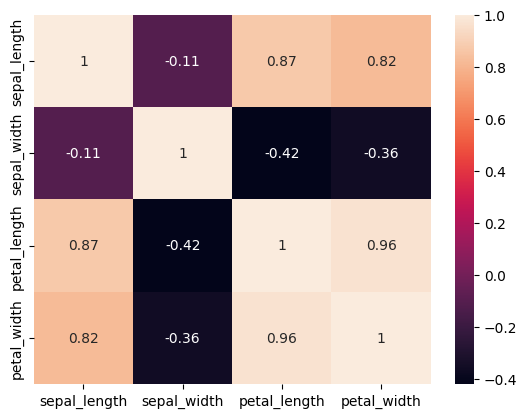

In [18]:
sns.heatmap(df.corr(numeric_only=True), annot=True)
plt.show()

<p style="text-align: justify;">The heatmap provides a visual representation of the correlation matrix using colors. Darker colors indicate stronger correlations, making it easy to identify highly related features. It confirms that petal measurements are strongly correlated with each other.</p>

**BarPlot**

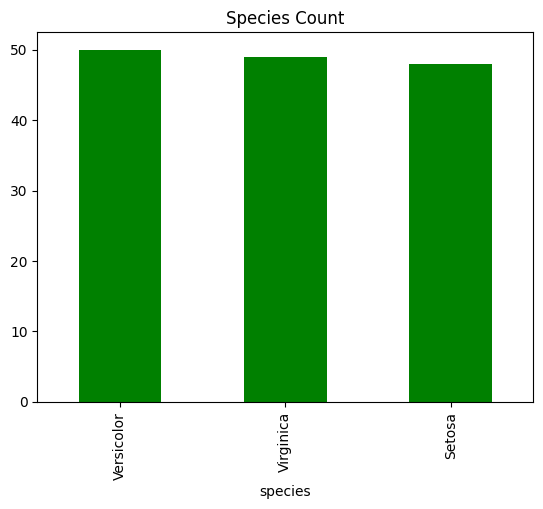

In [19]:
df['species'].value_counts().plot(kind='bar', color='green')
plt.title("Species Count")
plt.show()

<p style="text-align: justify;">The bar plot displays the number of observations for each Iris species. It shows that all three species have an equal number of samples, indicating that the dataset is balanced and suitable for comparative analysis.</p>

**Line Chart**

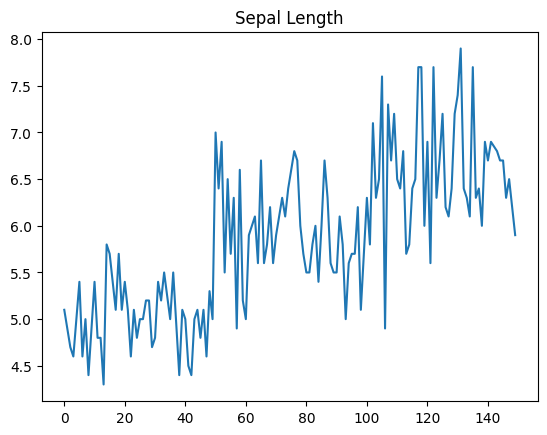

In [20]:
plt.plot(df['sepal_length'])
plt.title("Sepal Length")
plt.show()

<p style="text-align:justify">The line chart illustrates how a numerical feature changes across the dataset records. It shows the variation and trend of the selected feature over the observations, helping to identify fluctuations or patterns in the data.</p>

**Scatter Plot** 

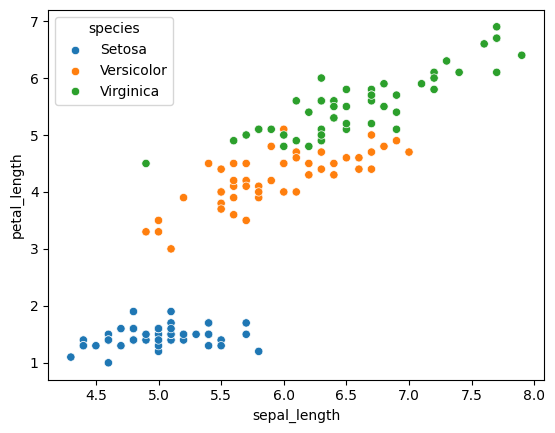

In [21]:
sns.scatterplot(x='sepal_length', y='petal_length', hue='species', data=df)
plt.show()

<p style="text-align:justify">The scatter plot shows the relationship between two numerical features. It indicates that petal length generally increases as sepal length increases, suggesting a positive relationship. The plot also helps visualize how different Iris species are distributed.</p>

**Select Featurs and Target Variable**

In [22]:
X = df[['sepal_length', 'sepal_width', 'petal_width']]
y = df['petal_length']

The independent variables (features) are selected as the input data (X), while the dependent variable (target) is selected as the output (y) that the model will predict.

**Split the DataSet**

In [23]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [24]:
print(X_train.shape)
print(X_test.shape)

(117, 3)
(30, 3)


The dataset is divided into training and testing sets. The training data is used to train the model, while the testing data is used to evaluate how well the model performs on unseen data.

**Create and Train the Linear Regression Model**

In [26]:
model = LinearRegression()
model.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


A Linear Regression model is created and trained using the training dataset. During training, the model learns the relationship between the input features and the target variable.

**Make Predictions**

In [28]:
y_pred = model.predict(X_test)
print(y_pred)

[4.84908108 4.14563793 6.09847961 1.41034715 4.10058569 1.43291773
 4.41573876 2.05759476 4.69152224 1.44416748 1.74242385 3.41398602
 5.48507894 3.80794966 5.58067976 5.04612505 1.88310352 4.28067942
 5.06295976 1.50607227 1.35973657 5.8621368  1.25844433 6.04782457
 3.18324601 1.01077193 4.03302487 6.81325235 3.87543941 1.30344334]


In [29]:
comparison = pd.DataFrame({
    'Actual': y_test,
    'Predicted': y_pred
})

comparison.head()

,Actual,Predicted
127,4.9,4.849081
53,4.0,4.145638
140,5.6,6.098480
19,1.5,1.410347
106,4.5,4.100586


After training, the model predicts the target values for the testing dataset. These predicted values are later compared with the actual values to measure model performance.

**Interpret the Model Coefficients** 

In [30]:
print("Intercept:", model.intercept_)
print("Coefficients:")
print(model.coef_)

Intercept: -0.46354148557672303
Coefficients:
[ 0.78792729 -0.67542976  1.40697522]


The regression coefficients show how much each feature influences the predicted value. A positive coefficient indicates a direct relationship, while a negative coefficient indicates an inverse relationship.

**Evaluate the Model using R-squared**

In [31]:
r2 = r2_score(y_test, y_pred)
print("R-squared:", r2)

R-squared: 0.9607788905754249


The R-squared (R²) score measures how well the model explains the variation in the target variable. A value closer to 1 indicates better model performance.

**Evaluate the Model using Mean Squared Error (MSE)**

In [33]:
mse = mean_squared_error(y_test, y_pred)
print("Mean Squared Error:", mse)

Mean Squared Error: 0.11479975149562685


Mean Squared Error (MSE) measures the average squared difference between the actual and predicted values. A lower MSE indicates better prediction accuracy.

**Visualize Actual vs Predicted Values**

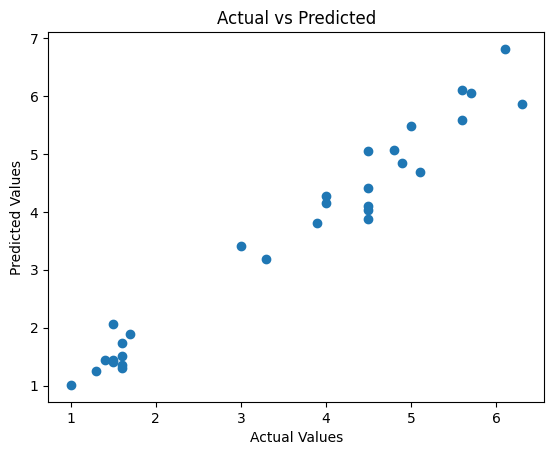

In [34]:
plt.scatter(y_test, y_pred)
plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")
plt.title("Actual vs Predicted")
plt.show()

A scatter plot is created to compare the actual values with the predicted values. If the points are close together, it indicates that the model is making accurate predictions.

**Select Numerical Features**

In [37]:
X = df[['sepal_length','sepal_width','petal_length','petal_width']]
print(X)

     sepal_length  sepal_width  petal_length  petal_width
0             5.1          3.5           1.4          0.2
1             4.9          3.0           1.4          0.2
2             4.7          3.2           1.3          0.2
3             4.6          3.1           1.5          0.2
4             5.0          3.6           1.4          0.2
..            ...          ...           ...          ...
145           6.7          3.0           5.2          2.3
146           6.3          2.5           5.0          1.9
147           6.5          3.0           5.2          2.0
148           6.2          3.4           5.4          2.3
149           5.9          3.0           5.1          1.8

[147 rows x 4 columns]


Only the numerical features are selected because K-Means clustering works with numerical data. The species column is excluded since K-Means is an unsupervised learning algorithm and does not use target labels during training.

**standardize the Dataset**

In [40]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
print(X_scaled)

[[-0.91550949  1.0199714  -1.35773692 -1.33570001]
 [-1.15755966 -0.12808217 -1.35773692 -1.33570001]
 [-1.39960983  0.33113926 -1.41477817 -1.33570001]
 [-1.52063491  0.10152855 -1.30069567 -1.33570001]
 [-1.03653457  1.24958212 -1.35773692 -1.33570001]
 [-0.55243423  1.93841426 -1.18661318 -1.07090176]
 [-1.52063491  0.79036069 -1.35773692 -1.20330089]
 [-1.03653457  0.79036069 -1.30069567 -1.33570001]
 [-1.76268509 -0.35769288 -1.35773692 -1.33570001]
 [-1.15755966  0.10152855 -1.30069567 -1.46809914]
 [-0.55243423  1.47919283 -1.30069567 -1.33570001]
 [-1.27858474  0.79036069 -1.24365442 -1.33570001]
 [-1.27858474 -0.12808217 -1.35773692 -1.46809914]
 [-1.88371017 -0.12808217 -1.52886066 -1.46809914]
 [-0.06833389  2.16802498 -1.47181942 -1.33570001]
 [-0.18935898  3.08646783 -1.30069567 -1.07090176]
 [-0.55243423  1.93841426 -1.41477817 -1.07090176]
 [-0.91550949  1.0199714  -1.35773692 -1.20330089]
 [-0.18935898  1.70880355 -1.18661318 -1.20330089]
 [-0.91550949  1.70880355 -1.30

The features are standardized so that each variable has a similar scale. This prevents variables with larger values from having a greater influence on the clustering process and improves the accuracy of the K-Means algorithm.

**To find the Optimal Number of Clusters**

In [42]:
# Create an empty list to store WCSS values
wcss = []

# Run K-Means for K = 1 to 10
for i in range(1, 11):
    
    # Create the K-Means model
    kmeans = KMeans(n_clusters=i, random_state=42)
    
    # Fit the model to the scaled data
    kmeans.fit(X_scaled)
    
    # Store the WCSS (Within-Cluster Sum of Squares)
    wcss.append(kmeans.inertia_)

In [43]:
print(wcss)

[587.9999999999999, 220.85907940742354, 139.06925981174987, 113.16810154166367, 90.18247360898815, 80.9137449359662, 72.54779193939929, 63.82234552780966, 59.46561243841943, 59.06736115192657]


The algorithm is trained using different numbers of clusters (1 to 10). For each value of K, the Within-Cluster Sum of Squares (WCSS) is calculated. Lower WCSS values indicate that the data points are closer to their cluster centers.

**Plot the Elbow Method**

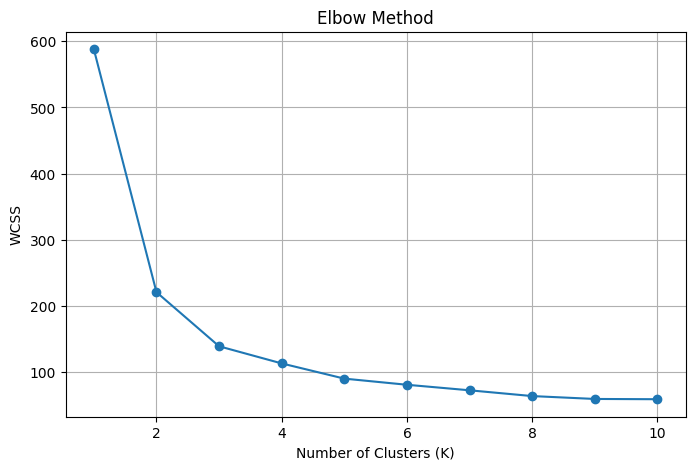

In [44]:
plt.figure(figsize=(8,5))
plt.plot(range(1, 11), wcss, marker='o')
plt.title("Elbow Method")
plt.xlabel("Number of Clusters (K)")
plt.ylabel("WCSS")
plt.grid(True)
plt.show()

The elbow plot is used to determine the optimal number of clusters. The point where the graph begins to flatten (forming an "elbow") indicates the most suitable number of clusters. For the Iris dataset, the optimal value is typically 3.

**Apply K-Means clustering**

In [46]:
kmeans = KMeans(n_clusters=3, random_state=42)
clusters = kmeans.fit_predict(X_scaled)
print(clusters)

[2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2
 2 2 0 2 2 2 2 2 2 2 2 1 1 1 0 1 0 1 0 1 0 0 0 0 0 0 1 0 0 0 0 1 0 0 0 0 1
 1 1 0 0 0 0 0 0 0 1 1 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 1 1 1 1 0 1 1 1 1 1 1
 0 1 1 1 1 1 0 1 0 1 1 1 1 1 1 1 1 1 1 1 1 0 1 1 1 1 1 1 1 1 1 1 0 1 1 1]


The K-Means algorithm groups similar observations into three clusters. Each observation is assigned a cluster label based on its similarity to the cluster centroid.

**Add Cluster Labels**

In [48]:
df['Cluster'] = clusters
df.head()

,sepal_length,sepal_width,petal_length,petal_width,species,Cluster
0,5.1,3.5,1.4,0.2,Setosa,2
1,4.9,3.0,1.4,0.2,Setosa,2
2,4.7,3.2,1.3,0.2,Setosa,2
3,4.6,3.1,1.5,0.2,Setosa,2
4,5.0,3.6,1.4,0.2,Setosa,2


A new column named Cluster is added to the dataset. This column stores the cluster number assigned to each observation, making it easier to analyze and visualize the clustering results.

**Visualize the Clusters**

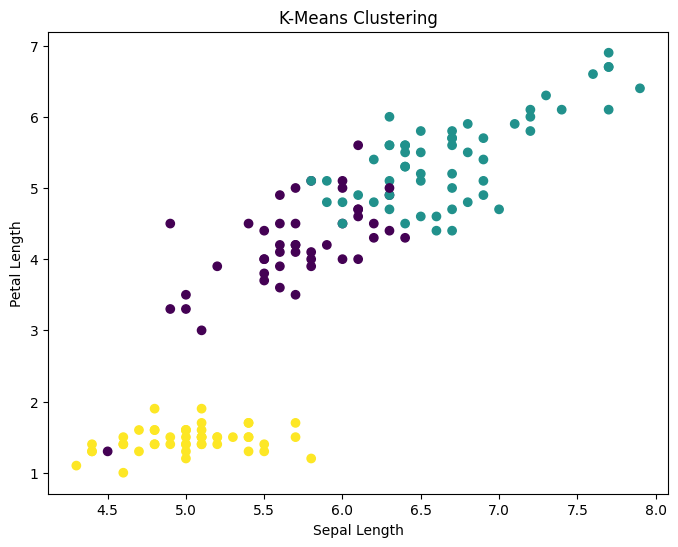

In [52]:
plt.figure(figsize=(8,6))
plt.scatter(df['sepal_length'],
            df['petal_length'],
            c=df['Cluster'])
plt.title("K-Means Clustering")

plt.xlabel("Sepal Length")

plt.ylabel("Petal Length")

plt.show()

A scatter plot is created to visualize the clusters. Each color represents a different cluster, allowing us to observe how the Iris flowers are grouped based on their sepal length and petal length.

**Count Observation in Each Cluster**

In [55]:
df['Cluster'].value_counts()

Cluster
1    55
2    47
0    45
Name: count, dtype: int64

This step counts the number of observations assigned to each cluster. It provides a summary of how the dataset is distributed across the identified clusters.

**Handle Categorical Variables**

In [58]:
encoder = LabelEncoder()
df["species"] = encoder.fit_transform(df["species"])
df.head(100)

,sepal_length,sepal_width,petal_length,petal_width,species,Cluster
0,5.1,3.5,1.4,0.2,0,2
1,4.9,3.0,1.4,0.2,0,2
2,4.7,3.2,1.3,0.2,0,2
3,4.6,3.1,1.5,0.2,0,2
4,5.0,3.6,1.4,0.2,0,2
...,...,...,...,...,...,...
97,6.2,2.9,4.3,1.3,1,0
98,5.1,2.5,3.0,1.1,1,0
99,5.7,2.8,4.1,1.3,1,0
100,6.3,3.3,6.0,2.5,2,1


Machine learning algorithms cannot work directly with text values. The species column contains flower names, so we convert them into numerical values using LabelEncoder. For example: 
Setosa= 0
Versicolor= 1
Virginica= 2

**Select features and target variable**

In [62]:
X = df.drop("species", axis=1)
y = df["species"]

The dataset is divided into two parts:
-Features (X): The input variables used to make predictions.
-Target (y): The output variable that we want to predict.
In our dataset first four columns are features and the species column is the target.

**Feature Scaling**

In [64]:
scaler = StandardScaler()
X = scaler.fit_transform(X)
print(X)

[[-0.91550949  1.0199714  -1.35773692 -1.33570001  1.24703791]
 [-1.15755966 -0.12808217 -1.35773692 -1.33570001  1.24703791]
 [-1.39960983  0.33113926 -1.41477817 -1.33570001  1.24703791]
 [-1.52063491  0.10152855 -1.30069567 -1.33570001  1.24703791]
 [-1.03653457  1.24958212 -1.35773692 -1.33570001  1.24703791]
 [-0.55243423  1.93841426 -1.18661318 -1.07090176  1.24703791]
 [-1.52063491  0.79036069 -1.35773692 -1.20330089  1.24703791]
 [-1.03653457  0.79036069 -1.30069567 -1.33570001  1.24703791]
 [-1.76268509 -0.35769288 -1.35773692 -1.33570001  1.24703791]
 [-1.15755966  0.10152855 -1.30069567 -1.46809914  1.24703791]
 [-0.55243423  1.47919283 -1.30069567 -1.33570001  1.24703791]
 [-1.27858474  0.79036069 -1.24365442 -1.33570001  1.24703791]
 [-1.27858474 -0.12808217 -1.35773692 -1.46809914  1.24703791]
 [-1.88371017 -0.12808217 -1.52886066 -1.46809914  1.24703791]
 [-0.06833389  2.16802498 -1.47181942 -1.33570001  1.24703791]
 [-0.18935898  3.08646783 -1.30069567 -1.07090176  1.24

The numerical features have different ranges. Feature scaling standardizes the values so that each feature has a similar scale. This improves the performance of many machine learning algorithms.

**Split the Dataset**

In [65]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

The dataset is divided into training and testing sets.
-Training set (80%) is used to train the model.
-Testing set (20%) is used to evaluate the model.

**Train the Decision Tree Model**

In [66]:
dt = DecisionTreeClassifier()
dt.fit(X_train, y_train)

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",None
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the curre

A Decision Tree classifier learns patterns by creating a tree-like structure of decisions. The model is trained using the training dataset.

**Make Predictions**

In [68]:
y_pred_dt = dt.predict(X_test)
print(y_pred_dt)

[2 1 2 0 1 0 1 0 2 0 0 1 2 1 2 1 0 1 2 0 0 2 0 2 1 0 1 2 1 0]


**Evaluate the Decision Tree Model**

In [72]:
accuracy_score(y_test, y_pred_dt)

0.9333333333333333

In [73]:
precision_score(y_test, y_pred_dt, average="weighted")

0.9333333333333333

In [74]:
recall_score(y_test, y_pred_dt, average="weighted")

0.9333333333333333

In [75]:
f1_score(y_test, y_pred_dt, average="weighted")

0.9333333333333333

After making predictions, we evaluate the model using different performance metrics.
- Accuracy measures the percentage of correct predictions.
- Precision measures how many predicted positive values are actually correct.
- Recall measures how many actual positive values are correctly predicted.
- F1-score is the balance between precision and recall.

**Train Logistic Regression**

In [76]:
lr = LogisticRegression()
lr.fit(X_train, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

Logistic Regression is another classification algorithm. It predicts the probability that an observation belongs to a particular class.

**Make Predict**

In [77]:
y_pred_lr = lr.predict(X_test)

**Evaluate the Logistic Regression with different performance metrics**

In [78]:
print("Accuracy:", accuracy_score(y_test, y_pred_lr))
print("Precision:", precision_score(y_test, y_pred_lr, average="weighted"))
print("Recall:", recall_score(y_test, y_pred_lr, average="weighted"))
print("F1 Score:", f1_score(y_test, y_pred_lr, average="weighted"))

Accuracy: 1.0
Precision: 1.0
Recall: 1.0
F1 Score: 1.0


**Train the Random Forest Model**

In [79]:
rf = RandomForestClassifier()
rf.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

Random Forest combines multiple decision trees and makes predictions based on the majority vote. It generally produces more accurate and reliable results than a single decision tree.

**Make Predict**

In [80]:
y_pred_rf = rf.predict(X_test)

**Evaluate the Random Forest with different performance metrics.**

In [81]:
print("Accuracy:", accuracy_score(y_test, y_pred_rf))
print("Precision:", precision_score(y_test, y_pred_rf, average="weighted"))
print("Recall:", recall_score(y_test, y_pred_rf, average="weighted"))
print("F1 Score:", f1_score(y_test, y_pred_rf, average="weighted"))

Accuracy: 0.9333333333333333
Precision: 0.9333333333333333
Recall: 0.9333333333333333
F1 Score: 0.9333333333333333


**Compare the Model**

In [82]:
print("Decision Tree Accuracy:",accuracy_score(y_test, y_pred_dt))
print("Logistic Regression Accuracy:",accuracy_score(y_test, y_pred_lr))
print("Random Forest Accuracy:",accuracy_score(y_test, y_pred_rf))

Decision Tree Accuracy: 0.9333333333333333
Logistic Regression Accuracy: 1.0
Random Forest Accuracy: 0.9333333333333333


Now compare the accuracy of all three models to determine which one performs the best on the Iris dataset.

**Hyperparameter Tuning**

In [83]:
parameters = {
    "max_depth": [2,3,4,5],
    "criterion": ["gini","entropy"]
}

Hyperparameters are settings that control how a machine learning model learns. Instead of choosing these values manually, GridSearchCV tests multiple combinations and selects the one that gives the best performance.
For the decision tree, we will test:
- max_depth: Maximum depth of the tree.
- criterion: Method used to split the data ('gini' or 'entropy')

**Apply Grid Search**

In [84]:
grid = GridSearchCV(
    DecisionTreeClassifier(),
    parameters,
    cv=5
)

In [85]:
grid.fit(X_train, y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",DecisionTreeClassifier()
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'criterion': ['gini', 'entropy'], 'max_depth': [2, 3, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",None
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter candidate is displayed;- >2 : the score is also displayed;- >3 : t

GridSearchCV tries all parameter combinations using cross-validation and identifies the best-performing model.

**Display the Best Parameters**

In [86]:
print(grid.best_params_)

{'criterion': 'entropy', 'max_depth': 5}


After Grid Search finishes, we can view the parameter combination that achieved the highest performance.

**Use the Best Model**

In [87]:
best_model = grid.best_estimator_

In [88]:
y_pred_best = best_model.predict(X_test)

The best model found by Grid Search is used to make predictions on the testing dataset.

**Evaluate the Best Model**

In [99]:
print("Accuracy:", accuracy_score(y_test, y_pred_best))
print("Precision:", precision_score(y_test, y_pred_best, average="weighted"))
print("Recall:", recall_score(y_test, y_pred_best, average="weighted"))
print("F1 Score:", f1_score(y_test, y_pred_best, average="weighted"))

Accuracy: 0.9333333333333333
Precision: 0.9333333333333333
Recall: 0.9333333333333333
F1 Score: 0.9333333333333333


Finally, evaluate the optimized model to see whether the hyperparameter tuning improved its performance.

In [100]:
# Save the cleaned or transformed dataset
df.to_csv("iris_cleaned_dataset.csv", index=False)